<a href="https://colab.research.google.com/github/angielopez03/Paradigmas/blob/main/notebook/udacity_cs344_hw1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!cmake -DOpenCV_DIR=/usr/lib/x86_64-linux-gnu/cmake/opencv4 ../src

CMake Deprecation Warning at CMakeLists.txt:8 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


-- Found OpenCV: /usr (found version "4.5.4")
CMake Warning (dev) at CMakeLists.txt:12 (find_package):
  Policy CMP0146 is not set: The FindCUDA module is removed.  Run "cmake
  --help-policy CMP0146" for policy details.  Use the cmake_policy command to
  set the policy and suppress this warning.

This warning is for project developers.  Use -Wno-dev to suppress it.

-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE
-- Found CUDA: /usr/local/cuda (found version "12.8")
CMake Deprecation Warning at HW3/CMakeLists.txt:8 (cmake_minimum_required):
  Compatibi

In [20]:
%%cuda --name student_func.cu

#include "utils.h"

__global__
void rgba_to_greyscale(const uchar4* const rgbaImage,
                       unsigned char* const greyImage,
                       int numRows, int numCols)
{
  int col = blockIdx.x * blockDim.x + threadIdx.x;
  int row = blockIdx.y * blockDim.y + threadIdx.y;

  if (col >= numCols || row >= numRows) return;

  int idx = row * numCols + col;
  uchar4 rgba = rgbaImage[idx];
  float grey = .299f * rgba.x + .587f * rgba.y + .114f * rgba.z;
  greyImage[idx] = (unsigned char)grey;
}

void your_rgba_to_greyscale(const uchar4 * const h_rgbaImage, uchar4 * const d_rgbaImage,
                            unsigned char* const d_greyImage, size_t numRows, size_t numCols)
{
  const dim3 blockSize(16, 16, 1);
  const dim3 gridSize((numCols + 15) / 16, (numRows + 15) / 16, 1);
  rgba_to_greyscale<<<gridSize, blockSize>>>(d_rgbaImage, d_greyImage, numRows, numCols);

  cudaDeviceSynchronize(); checkCudaErrors(cudaGetLastError());
}

'File written in /content/udacity-cs344-colab/src/HW1/student_func.cu'

In [25]:
!ls /content/udacity-cs344-colab/src/HW1/


cinque_terre.gold	compare.h  reference_calc.cpp  utils.h
cinque_terre_small.jpg	HW1.cpp    reference_calc.h
CMakeLists.txt		main.cpp   student_func.cu
compare.cpp		Makefile   timer.h


FileNotFoundError: [Errno 2] No such file or directory: 'HW1_output.png'

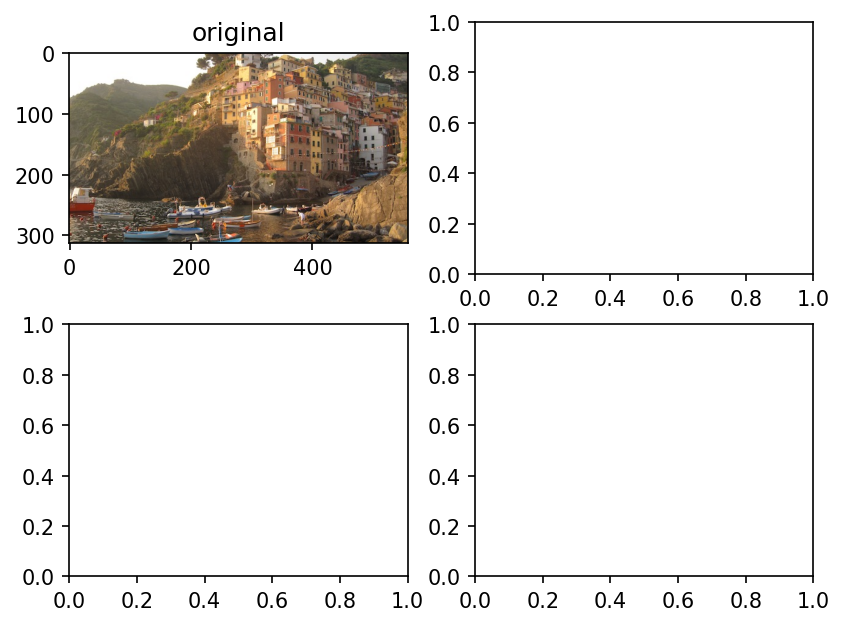

In [23]:
# plot output images
import matplotlib.pyplot as plt
_,ax = plt.subplots(2,2, dpi=150)

ax[0][0].imshow(plt.imread("../src/HW1/cinque_terre_small.jpg"))
ax[0][0].set_title("original")
ax[0][0].grid(False)

ax[0][1].imshow(plt.imread("HW1_output.png"))
ax[0][1].set_title("output")
ax[0][1].grid(False)

ax[1][0].imshow(plt.imread("HW1_reference.png"))
ax[1][0].set_title("reference")
ax[1][0].grid(False)

ax[1][1].imshow(plt.imread("HW1_differenceImage.png"))
ax[1][1].set_title("difference")
ax[1][1].grid(False)

plt.show()